#### Imports / configuration loading

In [1]:
# !git clone https://github.com/LikeScience/predictive_model_latent_space
# %cd predictive_model_latent_space/
# !pip install minigrid gymnasium

Cloning into 'predictive_model_latent_space'...
remote: Enumerating objects: 7699, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 7699 (delta 1), reused 0 (delta 0), pack-reused 7688 (from 3)
Receiving objects: 100% (7699/7699), 556.33 MiB | 23.70 MiB/s, done.
Resolving deltas: 100% (374/374), done.
Updating files: 100% (5528/5528), done.
/content/predictive_model_latent_space
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.7/136.7 kB 6.7 MB/s eta 0:00:00


In [10]:
# # Reload imports if needed
# import source
# import importlib
# importlib.reload(source.results_analysis)
# importlib.reload(source.train_predictive_models)
# importlib.reload(source.predictive_models)
# importlib.reload(source.exploration)
# importlib.reload(source.map_loader)


In [11]:

from source import agents, exploration, predictive_models
from source.map_loader import Env
from source.train_predictive_models import process_input, runSGD, runRMSProp, one_hot_encode
from source.results_analysis import metrics_predict_map,print_metrics,latent_space_PCA
from pathlib import Path
import source.results_analysis as results_analysis
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
import json
import os
import textwrap
from tqdm import tqdm
import pandas as pd
import seaborn as sns

map_files = ["levenstein_0.txt"]
map_labels = ["levenstein_0"]
dims = [[18,18]]
map_types = ["color"]
config_files = ["egocentric_7x7view_only_rnn.json","egocentric_7x7view_rnn_separate_action.json"]
seeds = [77243]
n_action_seq = [1]
configs = []

for config in config_files:
    with open(f"configs/reproduce_levenstein/{config}", 'r') as file:
       configs.append(json.load(file))

####  Data generation

In [3]:
loaded_data = [{k3: None for k3 in seeds} for i in range(len(map_files))]
observation_spaces = {"egocentric": exploration.exploration_egocentric,"allocentric":exploration.exploration_allocentric}

config = configs[0]
observation_space = config["observation_space"]

data_keys = ['img_train', 'pos_train', 'dir_train', 'img_test', 'pos_test', 'dir_test']
for c in range(len(map_files)):
    with open(f"maps/{map_files[c]}", 'r') as file:
        map = [[int(x) for x in line.strip().split(" ")] for line in file ]
    if (map_types[c]=="color"):
        with open(f"maps/colors/{map_files[c]}", 'r') as file:
            color_map = [[int(x) for x in line.strip().split(" ")] for line in file ]
    else:
        color_map = None
    env = Env(map,dims[c],tuple(config['start_pos']),seed=config['env_seed'],render_mode="rgb_array",agent_view_size=config['egocentric_view_size'])
    env.reset(seed=env.env_seed)
    for seed in seeds:
        if observation_space == "egocentric":
            agent_type = ["random", [0.1667, 0.1667, 0.6666],seed]
        elif observation_space == "allocentric":
            agent_type = ["random", [0.25, 0.25, 0.25, 0.25], seed]

        outfolder = f"exploration_data/reproduce_levenstein/{map_labels[c]}"
        outdir = f"{outfolder}/{seed}_exploration_data.npz"
        Path(outfolder).mkdir(parents=True, exist_ok=True)
        print(f"Setting:{c}, {observation_space}, {seed}")
        try:
            with np.load(outdir) as data:
                loaded_data[c][seed] = [data[k] for k in data_keys]
                print ("Successfully loaded data!")
        except (FileNotFoundError, Exception):
            config['agent_type'][2] = seed
            env = Env(map,dims[c],tuple(config['start_pos']),seed=seed,render_mode="rgb_array",agent_view_size=config['egocentric_view_size'],colors=color_map)
            env.reset(seed=env.env_seed)
            loaded_data[c][seed] = observation_spaces[observation_space](
            env,
            agent_type=agent_type,
            n_steps_train=config['number_steps_train'],
            n_steps_test=config['number_steps_test'],
            n_restart_train=config['num_random_position_restarts_train'],
            n_restart_test=config['num_random_position_restarts_test'],
            rgb_rep=True)
            exploration_data = loaded_data[c][seed]
            np.savez_compressed(outdir, **dict(zip(data_keys, exploration_data)))
            print ("Exploration complete!")


Setting:0, egocentric, 77243
Successfully loaded data!


In [ ]:

# env.step(2)
# print(env.agent_pos)
# plt.imshow(env.render())
# plt.axis('off')
# plt.show()

#### Training predictive models

In [12]:
config_names = [config["config_name"] for config in configs]
loaded_models = {k1: {k2: [{k3: None for k3 in seeds} for i in range(len(map_files))] for k2 in config_names} for k1 in n_action_seq}
processed_inputs = {k1: {k2: [{k3: None for k3 in seeds} for i in range(len(map_files))] for k2 in config_names} for k1 in n_action_seq}

for n_act in n_action_seq:
    for c in range(len(map_files)):
        for seed in tqdm(seeds):
            image_list_train, pos_list_train, dir_list_train, image_list_test, pos_list_test, dir_list_test = loaded_data[c][seed]
            X_train,X_test= torch.tensor(image_list_train, dtype=torch.int64),torch.tensor(image_list_test, dtype=torch.int64)

            target_train = X_train[n_act:]
            input_train = X_train[:-n_act]
            target_test = X_test[n_act:]
            input_test = X_test[:-n_act]

            train_actions = X_train[:,-1]
            test_actions = X_test[:,-1]
            input_train = torch.cat((input_train[:,:-1],train_actions.unfold(0, n_act, 1)[:-1]),dim=1)
            input_test = torch.cat((input_test[:,:-1],test_actions.unfold(0, n_act, 1)[:-1]),dim=1)

            scaling_factor=1

            print("hey")
            for config in configs:

                if config["observation_space"]=="allocentric":
                    img_width, img_height = config["map_dims"][0], config["map_dims"][1]
                else:
                    img_width, img_height = config["egocentric_view_size"], config["egocentric_view_size"]

                input_train_processed = torch.stack([process_input(x, 'in',img_width,img_height,scaling_factor,3,n_actions=n_act) for x in input_train])
                target_train_processed = torch.stack([process_input(x, 'out',img_width,img_height,scaling_factor,3,n_actions=n_act) for x in target_train])
                input_test_processed = torch.stack([process_input(x, 'in',img_width,img_height,scaling_factor,3,n_actions=n_act) for x in input_test])
                target_test_processed = torch.stack([process_input(x, 'out',img_width,img_height,scaling_factor,3,n_actions=n_act) for x in target_test])
                processed_inputs[n_act][config["config_name"]][c][seed] = [input_train_processed, input_test_processed, target_train_processed, target_test_processed]

                latent_size=config["latent_size"]
                hidden_fac=15
                img_channels=3
                input_size=input_train_processed.size(1)
                output_size = target_train_processed.size(1)
                torch.manual_seed(config["model_seed"])
                torch.use_deterministic_algorithms(True)
                train_flag = True
                device = torch.device('cpu' if torch.cuda.is_available() else 'cpu')
                if config['model_type'] == "rnn":
                    model = predictive_models.PredictiveRNN(img_width*img_height*img_channels, 3*n_act, latent_size,device, scaling_factor = 256, eta = 0.03, tau = 2)
                    training_algorithm = 'RMSProp'
                    model = torch.jit.script(model)
                elif config["model_type"]=="autoencoder_rnn_separate_action":
                    model = predictive_models.AutoencoderRNNSeparateAction(img_width*img_height*img_channels,input_size-img_width*img_height*img_channels, output_size, hidden_fac, latent_size+3*n_act,device)
                    training_algorithm = 'SGD'
                else:
                    model = predictive_models.AutoencoderInputs(img_width*img_height*img_channels,device)
                    train_flag = False
                model.to(device)
                n_epochs, batch_size = config['number_epochs'], config['batch_size']
                MODEL_PATH = f"trained_models/reproduce_levenstein/{n_act}_{config['predictive_model_path']}_{map_labels[c]}_{seed}.pt"
                METRICS_DIR = f"outputs/reproduce_levenstein/model_evaluation/{n_act}/{config['predictive_model_path']}_{map_labels[c]}_{seed}"
                Path(METRICS_DIR).mkdir(parents=True, exist_ok=True)
                METRICS_PATH = f"{METRICS_DIR}/metrics.csv"
                print("wait")
                if (config["load_trained_model_if_existent"] and os.path.exists(MODEL_PATH)) and config["model_type"]!="inputs":
                    try:
                        model.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=True))
                        print("Loaded model!")
                        with open(f"outputs/reproduce_levenstein/model_evaluation/{n_act}/{config['predictive_model_path']}_{map_labels[c]}_{seed}/metrics.json", "r") as f:
                            metrics = json.load(f)
                        train_flag = False
                    except (RuntimeError, KeyError, EOFError) as e:
                        print("Failed to load model - will proceed to training!")
                if train_flag:
                    if training_algorithm == 'SGD':
                        tracked_losses_train, tracked_losses_test = runSGD(model, input_train_processed, target_train_processed, input_test_processed, target_test_processed, device=device, n_epochs=n_epochs, batch_size=batch_size,seed=config["model_seed"],notrain=(not config["train"]))
                    elif training_algorithm == 'RMSProp':
                        tracked_losses_train, tracked_losses_test = runRMSProp(model, input_train_processed, target_train_processed, input_test_processed, target_test_processed, device=device, n_epochs=n_epochs, batch_size=batch_size,seed=config["model_seed"],notrain=(not config["train"]))
                    if (config['save_trained_model']):
                        torch.save(model.state_dict(), MODEL_PATH)
                    dec_outputs = results_analysis.metrics_predict_rgb_with_decoding(model,config,device,scaling_factor,input_test_processed,target_test_processed,tracked_losses_train,tracked_losses_test,outdir=METRICS_DIR,nbins=16,ego_len=img_width)

                loaded_models[n_act][config["config_name"]][c][seed] = model

  0%|          | 0/1 [00:00<?, ?it/s]

hey
wait



  2%|▏         | 1/50 [00:32<26:48, 32.83s/it]

7421.78857421875



  4%|▍         | 2/50 [01:05<26:13, 32.78s/it]

...


 98%|█████████▊| 49/50 [26:49<00:32, 32.38s/it]

2700.27880859375



  0%|          | 0/1 [27:34<?, ?it/s]

2681.029052734375


ZeroDivisionError: division by zero

In [ ]:
print(input_train_processed.shape)

torch.Size([79999, 150])


#### PCA on latent space

In [ ]:
top_components = {k1: {k2: [{k3: None for k3 in seeds} for i in range(len(map_files))] for k2 in config_names} for k1 in n_action_seq}

for n_act in n_action_seq:
    for c in range(len(map_files)):
        for seed in tqdm(seeds):
            OUT_DIR = f"outputs/reproduce_levenstein/latent_space_PCA/{map_labels[c]}_{n_act}/{seed}"
            if not os.listdir(OUT_DIR):
                input_train_processed = processed_inputs[n_act][config["config_name"]][c][seed][0]
                image_list_train, pos_list_train, dir_list_train, image_list_test, pos_list_test, dir_list_test = loaded_data[c][seed]
                model = loaded_models[n_act][config["config_name"]][c][seed]
                # latent_space_before, latent_space_after = model.get_latent(input_train_processed)
                all_latent_spaces = [(model.get_latent(i.view(1,-1).to(device))) for i in input_train_processed]
                latent_space_before = torch.stack([i[0] for i in all_latent_spaces]).squeeze(1)
                latent_space_after_list = [i[1] for i in all_latent_spaces]
                if all(val is not None for val in latent_space_after_list):
                    latent_space_after = torch.stack(latent_space_after_list).squeeze(1)
                else:
                    latent_space_after = None

                # if (config["model_type"] == "autoencoder_rnn"):
                #     latent_spaces = [[latent_space_before, "before_RNN"],[latent_space_after, "after_RNN"]]
                # else:
                latent_spaces = [[latent_space_before, ""]]
                print([n_act], config["config_name"], map_labels[c],seed)
                top_components[n_act][config["config_name"]][c][seed] = latent_space_PCA(latent_spaces,config,pos_list_train[:-n_act],dir_list_train[:-n_act],img_width,img_height,outdir=OUT_DIR)



##### Violin plots

In [ ]:
data_directories = [('outputs/multiple_action_sequences/latent_space_PCA','actions'), ('outputs/variances_egocentic_input_spaces/latent_space_PCA',' inputs')]
directories_to_use = ['8x8_colors', '20x20_colors', '50x50_colors']

def numeric_key(s):
    parts = s.replace('x', ' ').replace('_', ' ').split()
    return [int(p) for p in parts if p.isdigit()]

OUT_DIR_VAR = f"outputs/multiple_action_sequences/latent_space_PCA/"
Path(OUT_DIR_VAR).mkdir(parents=True, exist_ok=True)
values, labels = [],[]
metric_label = "variance of first 3 principal components"
for data_directory,label in data_directories:
    print(sorted(os.listdir(data_directory),reverse=True))
    for map_label in sorted(os.listdir(data_directory), key=numeric_key):
        if map_label[-4:] != ".png" and (data_directory == 'outputs/multiple_action_sequences/latent_space_PCA' or map_label in directories_to_use):
            print(map_label)
            values.append([])
            labels.append(map_label+label)
            for seed in sorted(os.listdir(f"{data_directory}/{map_label}"),reverse=True):
                for filename in sorted(os.listdir(f"{data_directory}/{map_label}/{seed}"),reverse=True):
                    if filename.endswith('.json'):
                        path = os.path.join(Path(f"{data_directory}/{map_label}/{seed}"), filename)
                        with open(path, 'r') as f:
                            data = json.load(f)
                            values[-1] += [data["cumulative_variance"][2]]

wrapped_labels = [textwrap.fill(label, width=30) for label in labels]
df = pd.DataFrame([{'L': l, 'V': v} for l, vs in zip(wrapped_labels, values) for v in vs])
plt.figure(figsize=(8, 6))
sns.violinplot(data=df, x='V', y='L',hue= 'L', palette='viridis', inner='box', linewidth=1.5)
plt.ylabel('Model type'); plt.xlabel(f"PCA {metric_label}")
plt.savefig(f"{OUT_DIR_VAR}/variance_violin_zoom.png", bbox_inches='tight')
plt.xlim(0, 1)
plt.savefig(f"{OUT_DIR_VAR}/variance_violin.png", bbox_inches='tight'); plt.clf()

['variance_violin_zoom.png', 'variance_violin.png', '8x8_colors_8', '8x8_colors_4', '8x8_colors_2', '8x8_colors_16', '8x8_colors_1', '50x50_colors_8', '50x50_colors_4', '50x50_colors_2', '50x50_colors_16', '50x50_colors_1', '20x20_colors_8', '20x20_colors_4', '20x20_colors_2', '20x20_colors_16', '20x20_colors_1']
8x8_colors_1
8x8_colors_2
8x8_colors_4
8x8_colors_8
8x8_colors_16
20x20_colors_1
20x20_colors_2
20x20_colors_4
20x20_colors_8
20x20_colors_16
50x50_colors_1
50x50_colors_2
50x50_colors_4
50x50_colors_8
50x50_colors_16
['variance_violin_zoom.png', 'variance_violin.png', '8x8_walls', '8x8_empty', '8x8_colorswalls', '8x8_colors', '50x50_walls', '50x50_empty', '50x50_colorswalls', '50x50_colors', '20x20_walls', '20x20_empty', '20x20_colorswalls', '20x20_colors', '14x14_walls', '14x14_empty', '14x14_colorswalls', '14x14_colors']
8x8_colors
20x20_colors
50x50_colors


<Figure size 800x600 with 0 Axes>

#### Firing fields

In [ ]:
top_components = {k1: {k2: [{k3: None for k3 in seeds} for i in range(len(map_files))] for k2 in config_names} for k1 in n_action_seq}

units_to_test = [z for z in range(50)]
firing_fields = [{k1: {k2: [{k3: [[0 for _ in range(dims[i][0])] for _ in range(dims[i][1])] for k3 in seeds} for i in range(len(map_files))] for k2 in config_names} for k1 in n_action_seq} for _ in range(len(units_to_test))]

for n_act in n_action_seq:
    for c in range(len(map_files)):
        for seed in tqdm(seeds):
            OUT_DIR = f"outputs/multiple_action_sequences/latent_space_PCA/{map_labels[c]}_{n_act}/{seed}"
            input_train_processed = processed_inputs[n_act][config["config_name"]][c][seed][0]
            image_list_train, pos_list_train, dir_list_train, image_list_test, pos_list_test, dir_list_test = loaded_data[c][seed]
            model = loaded_models[n_act][config["config_name"]][c][seed]
            # latent_space_before, latent_space_after = model.get_latent(input_train_processed)
            all_latent_spaces = [(model.get_latent(i.view(1,-1).to(device))) for i in input_train_processed]
            latent_space_before = torch.stack([i[0] for i in all_latent_spaces]).squeeze(1)
            latent_space_after_list = [i[1] for i in all_latent_spaces]
            if all(val is not None for val in latent_space_after_list):
                latent_space_after = torch.stack(latent_space_after_list).squeeze(1)
            else:
                latent_space_after = None
            latent_spaces = [[latent_space_before, ""]]
            print(n_act, config["config_name"], map_labels[c],seed)
            # print(latent_space_before)
            activations = latent_space_before.mean(dim=0) # Average firing per unit
            dead_units = (activations == 0).sum().item()
            total_units = activations.shape[0]
            print(dead_units,total_units)
            for u in range(len(units_to_test)):

                SAVE_PATH = f"outputs/multiple_action_sequences/firing_fields/{map_labels[c]}_{n_act}"
                os.makedirs(SAVE_PATH, exist_ok=True)
                if (z[0][u].mean(dim=0) > 0):
                    for z in zip(latent_space_before, pos_list_train):
                        x, y = z[1]
                        firing_fields[u][n_act][config["config_name"]][c][seed][x][y] += (z[0][units_to_test[u]].detach().cpu().item() > 0)
                    field = firing_fields[u][n_act][config["config_name"]][c][seed]
                    plt.imshow(field, cmap='viridis', origin='lower')
                    plt.title(f"Unit {units_to_test[u]}, Map {map_labels[c]}, Seed, {seed}, {n_act} actions")
                    plt.savefig(f"{SAVE_PATH}/seed_{seed}_unit_{units_to_test[u]}.png")
                    plt.close()




  0%|          | 0/3 [00:00<?, ?it/s]

1 egocentric_empty_7x7view_rnn_separate_action 8x8_colors 77243
38 50


 33%|███▎      | 1/3 [00:13<00:27, 13.55s/it]

1 egocentric_empty_7x7view_rnn_separate_action 8x8_colors 798315
37 50


 67%|██████▋   | 2/3 [00:25<00:12, 12.43s/it]

...

 33%|███▎      | 1/3 [00:10<00:21, 10.99s/it]

16 egocentric_empty_7x7view_rnn_separate_action 50x50_colors 798315
35 50


 67%|██████▋   | 2/3 [00:24<00:12, 12.29s/it]

16 egocentric_empty_7x7view_rnn_separate_action 50x50_colors 101125
34 50


100%|██████████| 3/3 [00:35<00:00, 11.75s/it]


#### Single layer decoders

In [ ]:
for n_act in n_action_seq:
    for c in range(len(map_files)):
        for seed in tqdm(seeds):
            model = loaded_models[n_act][config["config_name"]][c][seed]
            input_train_processed, input_test_processed = processed_inputs[n_act][config["config_name"]][c][seed][:2]
            image_list_train, pos_list_train, dir_list_train, image_list_test, pos_list_test, dir_list_test = loaded_data[c][seed]
            if config["observation_space"]=="allocentric":
                img_width, img_height = config["map_dims"][0], config["map_dims"][1]
            else:
                img_width, img_height = config["egocentric_view_size"], config["egocentric_view_size"]
            OUT_DIR_REPR = f"outputs/multiple_action_sequences/decode_latent_representations/{map_labels[c]}_{n_act}/{seed}"
            latent_size=config["latent_size"]+3*n_act
            Path(OUT_DIR_REPR).mkdir(parents=True, exist_ok=True)

            latent_space_before_train, latent_space_after_train = model.get_latent(input_train_processed.to(device))
            latent_space_before_test, latent_space_after_test = model.get_latent(input_test_processed.to(device))

            latent_size_repr = config["latent_size"]
            latent_representations_train = [[latent_space_before_train.detach(), ""]]
            latent_representations_test = [[latent_space_before_test.detach(), ""]]

            dads = []
            for i in range(len(latent_representations_train)):
                latent_representation_train, label = latent_representations_train[i]
                latent_representation_test, label = latent_representations_test[i]
                if not Path(f"{OUT_DIR_REPR}/{label}.json").exists():
                    dict_repr = {}
                    for variable in config["variables_for_training_decoder"]:
                        if variable == "position":
                                target_train_repr, target_test_repr = torch.tensor(pos_list_train[:-n_act]).float(), torch.tensor(pos_list_test[:-n_act]).float()
                                decoder_model = nn.Linear(latent_size_repr,2)
                                loss_type="mse"
                                metric, metric_label, output_process = results_analysis.accuracy, "accuracy",results_analysis.round
                        elif variable == "L2_dist_center":
                            target_train_repr = torch.tensor(np.sqrt((np.array(pos_list_train)[:-n_act,0]-(img_width-1)/2)**2+ (np.array(pos_list_train)[:-n_act,1]-(img_height-1)/2)**2)).float().unsqueeze(-1)
                            target_test_repr = torch.tensor(np.sqrt((np.array(pos_list_test)[:-n_act,0]-(img_width-1)/2)**2+ (np.array(pos_list_test)[:-n_act,1]-(img_height-1)/2)**2)).float().unsqueeze(-1)
                            decoder_model = nn.Linear(latent_size_repr,1)
                            loss_type="mse"
                            metric, metric_label, output_process = results_analysis.mse, "mse",results_analysis.identity
                        elif variable == "head_direction":
                            target_train_repr, target_test_repr = torch.tensor(dir_list_train[:-n_act]).long().view(-1), torch.tensor(dir_list_test[:-n_act]).long().view(-1)
                            decoder_model = nn.Linear(latent_size_repr,4)
                            loss_type="cel"
                            metric, metric_label, output_process = results_analysis.accuracy, "accuracy", results_analysis.argmax
                        tracked_losses_train_repr, tracked_losses_test_repr = runSGD(decoder_model,latent_representation_train,target_train_repr,latent_representation_test,target_test_repr,device,criterion=loss_type,n_epochs=100,batch_size=256,shuffle=False,hide_plot=True,lr=.01)
                        output_test_repr = decoder_model(latent_representation_test)
                        output_test_repr = output_process(output_test_repr)
                        results_repr = {}
                        results_repr["name_setting"] = f"{map_labels[c]}_{n_act} {seed}{label}"
                        results_repr["metric"] = metric(output_test_repr.cpu(), target_test_repr.cpu())
                        results_repr["metric_name"] = metric_label
                        results_repr["tracked_losses_test"] = tracked_losses_test_repr
                        dict_repr[variable] = results_repr
                        print(results_repr)
                        print(decoder_model.weight.grad.abs().mean())
                        dads += [output_test_repr,target_test_repr]

                    with open(f"{OUT_DIR_REPR}/{label}.json", "w") as f:
                        json.dump(dict_repr, f, indent=4)


  0%|          | 0/3 [00:00<?, ?it/s]

Epoch 	 Loss train 	 Loss test
1/100	 5.7423		 5.7834
2/100	 4.3563		 4.5813
3/100	 4.3427		 4.6132
4/100	 4.3998		 4.6932
5/100	 4.1251		 4.4721
6/100	 3.9367		 4.3379
7/100	 3.9224		 4.3510
8/100	 3.9599		 4.4077
9/100	 4.0367		 4.4984
10/100	 4.1240		 4.5904
11/100	 4.1806		 4.6425
12/100	 4.1893		 4.6411
13/100	 4.1605		 4.6001
14/100	 4.1134		 4.5405
15/100	 4.0640		 4.4795
16/100	 4.0219		 4.4269
17/100	 3.9915		 4.3871
18/100	 3.9733		 4.3606
19/100	 3.9658		 4.3459
20/100	 3.9666		 4.3405
21/100	 3.9732		 4.3418
22/100	 3.9833		 4.3475
23/100	 3.9951		 4.3556
24/100	 4.0073		 4.3648
25/100	 4.0191		 4.3741
26/100	 4.0300		 4.3830
27/100	 4.0399		 4.3912
28/100	 4.0485		 4.3985
29/100	 4.0561		 4.4050
30/100	 4.0626		 4.4106
31/100	 4.0682		 4.4155
32/100	 4.0730		 4.4197
33/100	 4.0772		 4.4234
34/100	 4.0807		 4.4265
35/100	 4.0838		 4.4293
36/100	 4.0864		 4.4316
37/100	 4.0887		 4.4337
38/100	 4.0906		 4.4354
39/100	 4.0923		 4.4370
40/100	 4.0938		 4.4384
41/100	 4.0951		 4

 33%|███▎      | 1/3 [00:28<00:57, 28.69s/it]

98/100	 1.6674		 1.7882
99/100	 1.6673		 1.7882
100/100	 1.6673		 1.7882
{'name_setting': '8x8_colors_2 77243', 'metric': 0.20440882444381714, 'metric_name': 'accuracy', 'tracked_losses_test': [1.7633635997772217, 1.7061513662338257, 1.750130295753479, 1.764212727546692, 1.7713065147399902, 1.7772326469421387, 1.7826436758041382, 1.7864160537719727, 1.7878376245498657, 1.78777277469635, 1.7873473167419434, 1.786969780921936, 1.7867050170898438, 1.7865427732467651, 1.7864601612091064, 1.786434292793274, 1.78644859790802, 1.786491870880127, 1.7865574359893799, 1.7866394519805908, 1.7867350578308105, 1.786840796470642, 1.786955714225769, 1.787077784538269, 1.7872047424316406, 1.7873356342315674, 1.7874674797058105, 1.787601113319397, 1.787732720375061, 1.7878625392913818, 1.7879887819290161, 1.788110613822937, 1.7882276773452759, 1.7883384227752686, 1.7884420156478882, 1.7885395288467407, 1.788629412651062, 1.7887123823165894, 1.7887872457504272, 1.7888553142547607, 1.7889155149459839, 1.

 67%|██████▋   | 2/3 [00:54<00:27, 27.27s/it]

...

 33%|███▎      | 1/3 [00:28<00:56, 28.13s/it]

100/100	 1.7033		 1.7360
{'name_setting': '20x20_colors_4 77243', 'metric': 0.2811245024204254, 'metric_name': 'accuracy', 'tracked_losses_test': [2.4617464542388916, 1.862044095993042, 1.854746699333191, 1.833207368850708, 1.8640886545181274, 1.902695894241333, 1.7888481616973877, 1.86226224899292, 1.9102277755737305, 1.7862495183944702, 1.8314049243927002, 1.7805707454681396, 1.6490552425384521, 1.8033018112182617, 1.7744263410568237, 1.733765721321106, 1.8983216285705566, 1.8053216934204102, 1.8139570951461792, 1.8141006231307983, 1.6567693948745728, 1.795588731765747, 1.711117148399353, 1.632763385772705, 1.80128812789917, 1.7912490367889404, 1.7051881551742554, 1.7464512586593628, 1.8911863565444946, 1.6875666379928589, 1.6450629234313965, 1.5837527513504028, 1.5747361183166504, 1.609184741973877, 1.607380986213684, 1.5816134214401245, 1.6106131076812744, 1.7717174291610718, 1.6085360050201416, 1.6299808025360107, 1.5986831188201904, 1.5699959993362427, 1.6074389219284058, 1.71119

 33%|███▎      | 1/3 [00:44<01:28, 44.17s/it]

69/100	 69.3584		 60.0943
70/100	 69.3604		 60.0970


KeyboardInterrupt: 

#### Environment cover

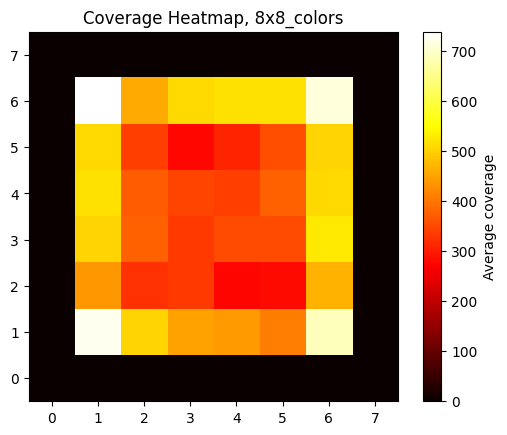

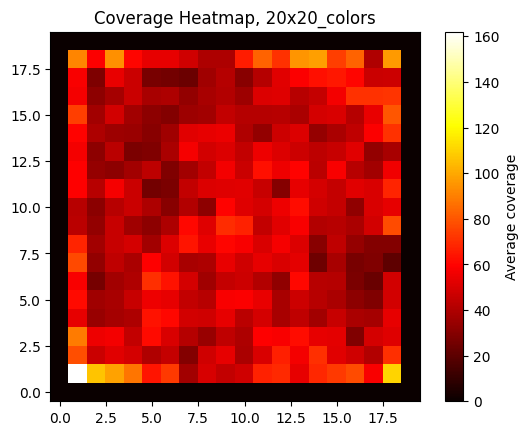

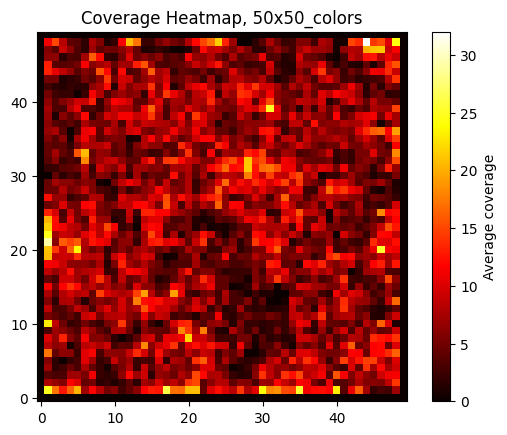

In [ ]:
for c in range(len(map_files)):
    map_width, map_height = dims[c]
    seeds_data = np.zeros((len(seeds), map_width, map_height))
    for s, seed in enumerate(seeds):
        coords = np.array(loaded_data[c][seed][1])
        if coords.size > 0:
            np.add.at(seeds_data[s], (coords[:,0], coords[:,1]), 1)
    avg_cover = np.mean(seeds_data, axis=0)

    plt.imshow(avg_cover, cmap='hot', interpolation='nearest',vmin=0,vmax=800)
    plt.imshow(avg_cover, cmap='hot', interpolation='nearest')
    plt.gca().invert_yaxis()
    plt.colorbar(label='Average coverage')
    plt.title(f"Coverage Heatmap, {map_labels[c]}")
    plt.show()

#### View env

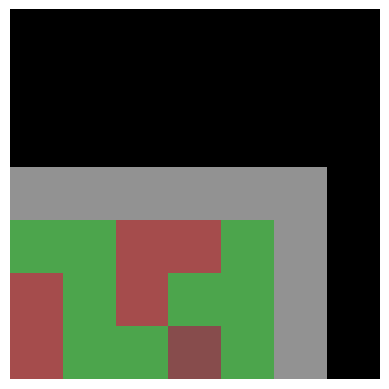

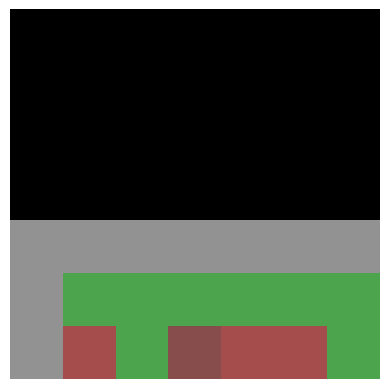

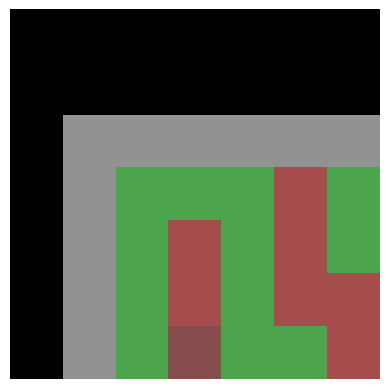

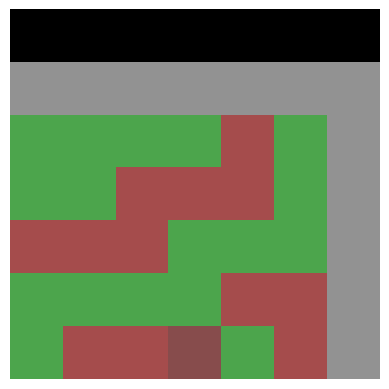

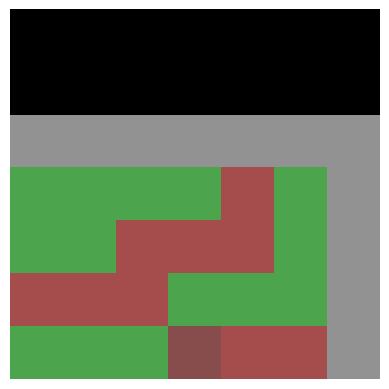

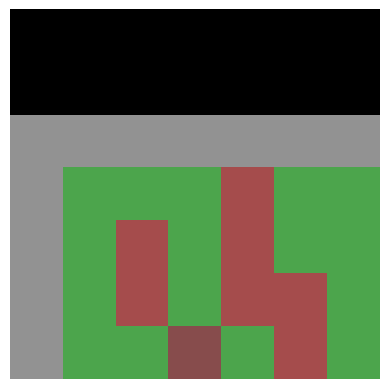

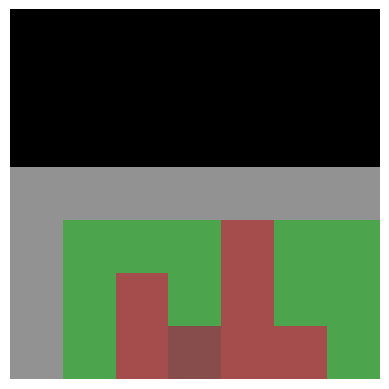

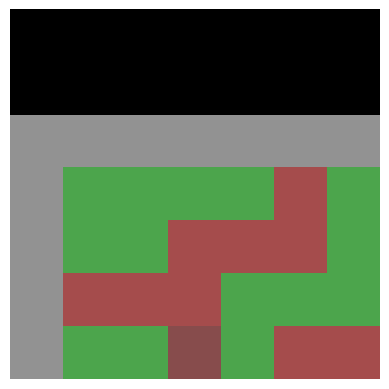

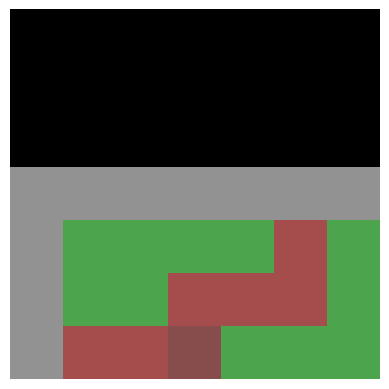

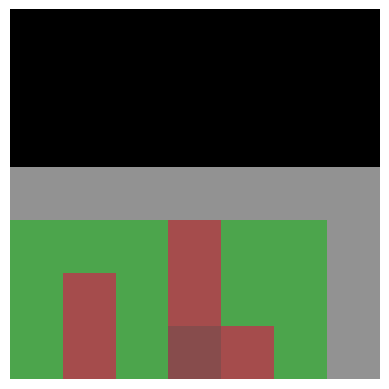

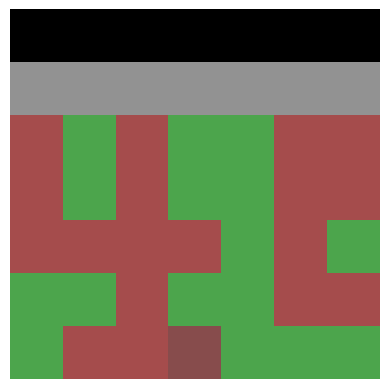

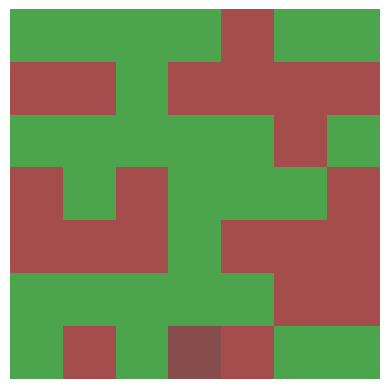

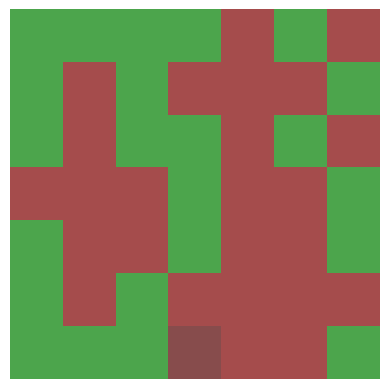

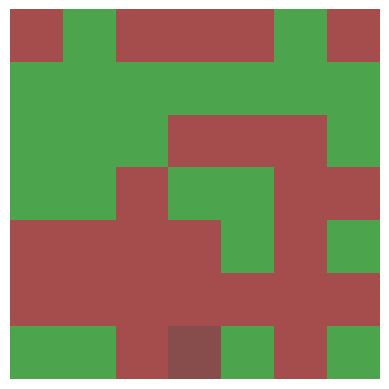

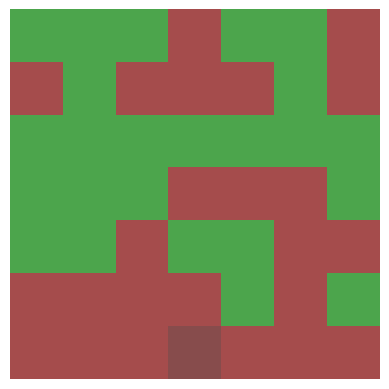

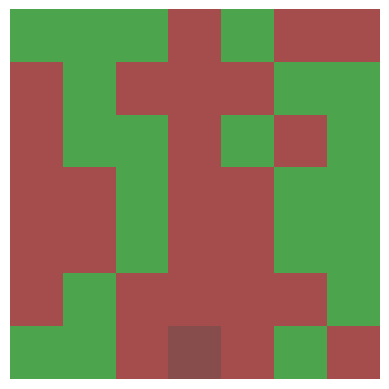

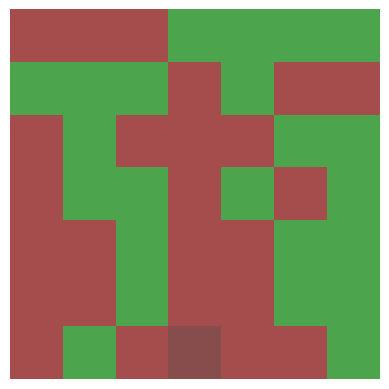

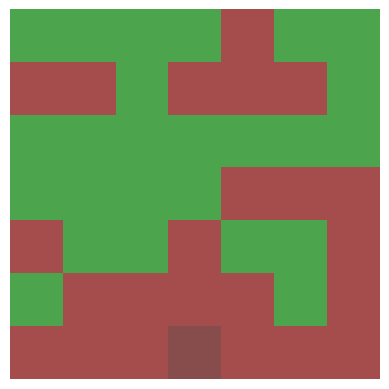

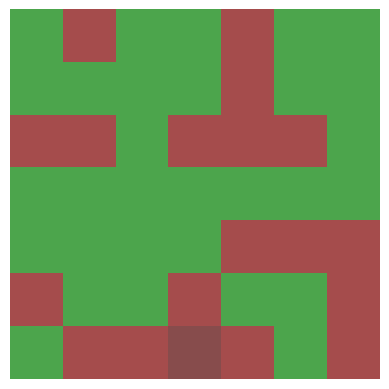

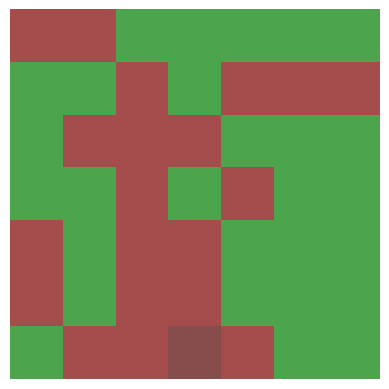

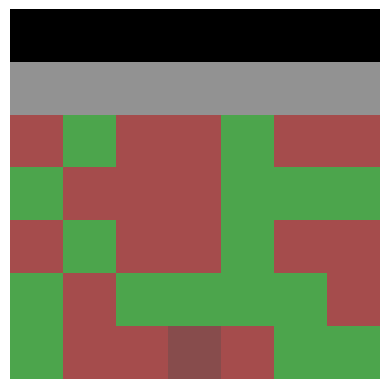

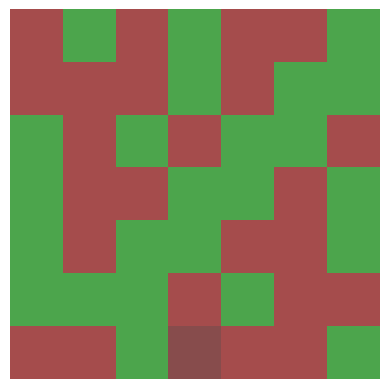

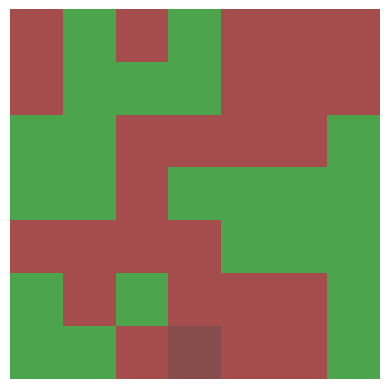

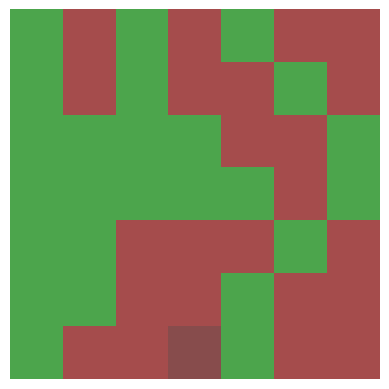

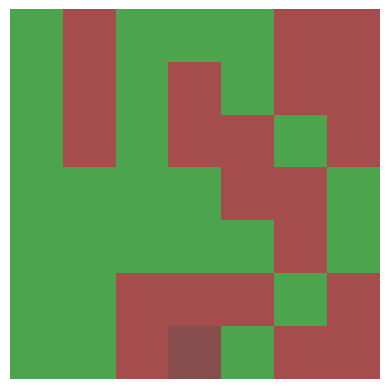

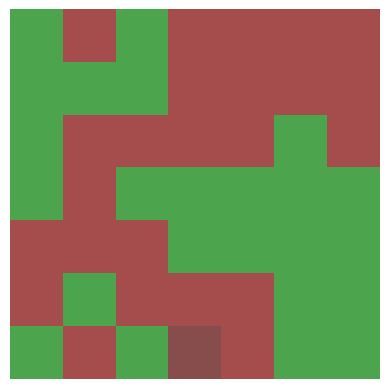

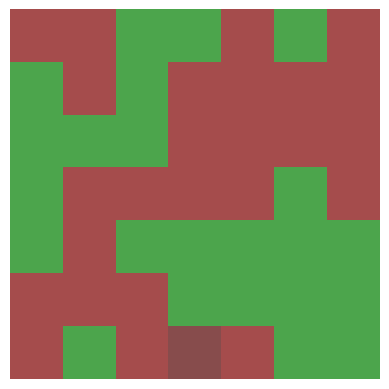

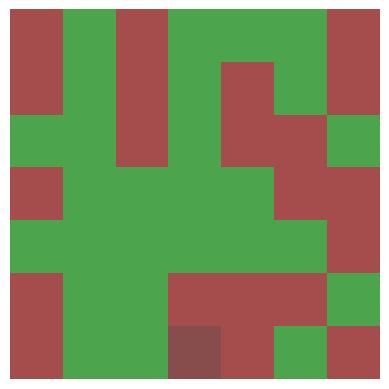

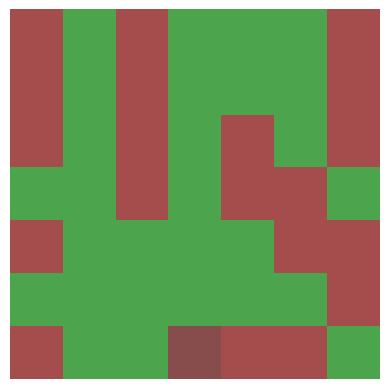

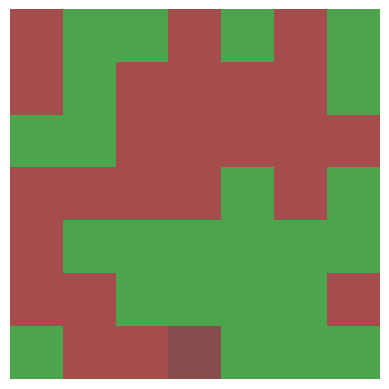

In [ ]:
for c in range(len(map_labels)):
    ar = np.array(loaded_data[c][77243][0])[:,:-1]
    img = ar.reshape(-1,7, 7, 3).astype(np.uint8)

    for i in range(150,160):
        plt.imshow(img[i], interpolation='nearest')
        plt.axis('off') # Hide pixel coordinates
        plt.show()